<a href="https://colab.research.google.com/github/jose-luis-hernandez-amaya/Simulaci-n-1/blob/main/Tercer_parcial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Linea de espera con 2 filas

In [22]:
import random as r
import matplotlib.pyplot as plt

Este modelo implementa la simulación por eventos discretos de un sistema en el que
    las entidades arriban según un Proceso de Poisson con tasa λ, y reciben servicio
    secuencial en dos nodos con tiempos de servicio distribuidos exponencialmente
    (tasas μ1 y μ2).

In [23]:
def simulacion_servidores_serie(tiempo_total, tasa_llegada, tasa_serv_1, tasa_serv_2):
    t = 0
    N_A = 0 # Llegadas totales al sistema
    N_D = 0 # Salidas totales del sistema

    n1 = 0
    n2 = 0

    t_A = r.expovariate(tasa_llegada) # Hora de la siguiente llegada
    t_1 = float('inf')                # Hora de salida del servidor 1
    t_2 = float('inf')                # Hora de salida del servidor 2

    historico_t = [0]
    historico_n1 = [0]
    historico_n2 = [0]

    while t <= tiempo_total:
        # Encontramos cuál es el evento inminente (el más cercano en el tiempo)
        min_evento = min(t_A, t_1, t_2)

        # CASO 1: Llegada de un cliente al sistema (Servidor 1)
        if min_evento == t_A:
            t = t_A
            N_A += 1
            n1 += 1
            t_A = t + r.expovariate(tasa_llegada)
            if n1 == 1:
                # El servidor 1 estaba libre, entra directo a servicio
                t_1 = t + r.expovariate(tasa_serv_1)

        # CASO 2: Cliente termina en el Servidor 1 y pasa al Servidor 2
        elif min_evento == t_1:
            t = t_1
            n1 -= 1
            n2 += 1

            # Actualizamos el estado del Servidor 1
            if n1 == 0:
                t_1 = float('inf')
            else:
                t_1 = t + r.expovariate(tasa_serv_1)

            # Actualizamos el estado del Servidor 2
            if n2 == 1:
                # El servidor 2 estaba libre esperándolo, entra directo a servicio
                t_2 = t + r.expovariate(tasa_serv_2)

        # CASO 3: Cliente termina en el Servidor 2 y sale del sistema
        elif min_evento == t_2:
            t = t_2
            N_D += 1
            n2 -= 1 # Abandona el sistema por completo

            # Actualizamos el estado del Servidor 2
            if n2 == 0:
                t_2 = float('inf')
            else:
                t_2 = t + r.expovariate(tasa_serv_2)

        historico_t.append(t)
        historico_n1.append(n1)
        historico_n2.append(n2)

    return historico_t, historico_n1, historico_n2, N_A, N_D

En este caso, en el ejemplo colocaoms un tiempo total de 24 horas, con un promedio de 10 persona llegadas / hora.
Se puede modidicar para simular otras situaciones

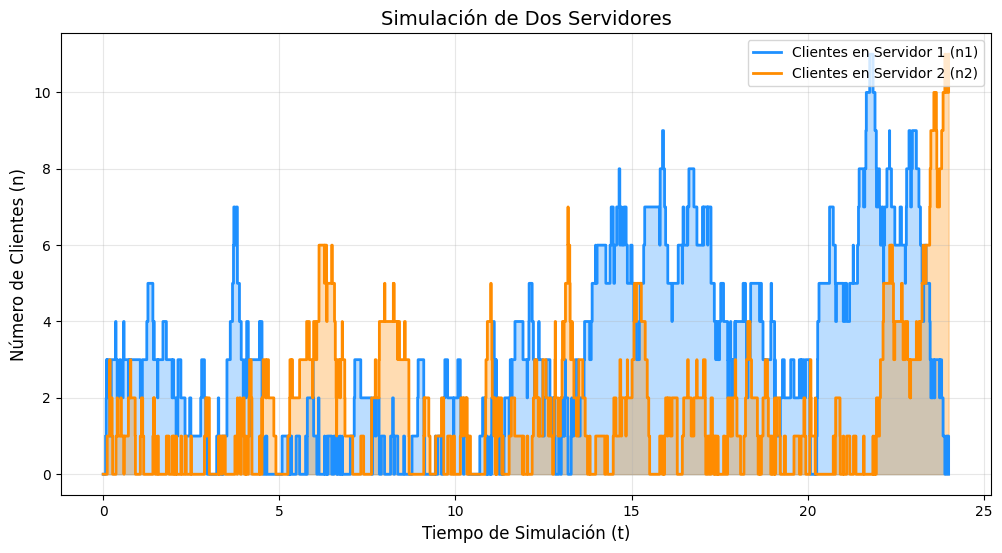

--- RESUMEN DE LA SIMULACIÓN ---
Total de clientes que entraron al sistema: 218
Total de clientes que completaron ambos servicios: 207
Clientes que se quedaron atrapados en la fila 1 al cortar el tiempo: 0
Clientes que se quedaron atrapados en la fila 2 al cortar el tiempo: 11


In [24]:
# Ejemplo
T, N1, N2, Total_Llegadas, Total_Salidas = simulacion_servidores_serie(
    tiempo_total=24,
    tasa_llegada=10,
    tasa_serv_1=12,
    tasa_serv_2=15
)

plt.figure(figsize=(12, 6))

plt.step(T, N1, where='post', color='dodgerblue', linewidth=2, label='Clientes en Servidor 1 (n1)')
plt.fill_between(T, 0, N1, step="post", alpha=0.3, color='dodgerblue')

plt.step(T, N2, where='post', color='darkorange', linewidth=2, label='Clientes en Servidor 2 (n2)')
plt.fill_between(T, 0, N2, step="post", alpha=0.3, color='darkorange')

plt.xlabel('Tiempo de Simulación (t)', fontsize=12)
plt.ylabel('Número de Clientes (n)', fontsize=12)
plt.title('Simulación de Dos Servidores', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

print("--- RESUMEN DE LA SIMULACIÓN ---")
print(f"Total de clientes que entraron al sistema: {Total_Llegadas}")
print(f"Total de clientes que completaron ambos servicios: {Total_Salidas}")
print(f"Clientes que se quedaron atrapados en la fila 1 al cortar el tiempo: {N1[-1]}")
print(f"Clientes que se quedaron atrapados en la fila 2 al cortar el tiempo: {N2[-1]}")

# Variables antitéticas aplicadas a la estimación de la integral de:
$$\int_0^1 e^{x^{2}}$$

La base del método de Monte Carlo crudo para calcular $\int_0^1 f(x) dx$ es generar números aleatorios $U$ entre 0 y 1, evaluar la función en esos números y sacar el promedio.

Las variables antitéticas usan la siguiente metodología: si $U$ es un número aleatorio entre 0 y 1, entonces $(1 - U)$ también es un número aleatorio perfectamente válido entre 0 y 1.

In [25]:
import numpy as np

  Calcula la integral usando el método de Monte Carlo tradicional.
  Se generan '2n' números aleatorios para que la comparación sea justa(ya que el método antitético hace 2 evaluaciones por cada 'n').

  En el Monte Carlo tradicional, generamos $2n$ variables aleatorias independientes $U_i \sim Uniforme(0,1)$ para estimar la integral. El estimador es el promedio simple:$$\hat{I}_{MC} = \frac{1}{2n} \sum_{i=1}^{2n} f(U_i)$$Por propiedades de la estadística, la varianza  de este estimador es simplemente la varianza de la función dividida por el total de muestras:$$Var(\hat{I}_{MC}) = \frac{Var(f(U))}{2n}$$

In [26]:
def integral_monte_carlo_crudo(n):
    # Generamos 2n números aleatorios entre 0 y 1
    U = np.random.uniform(0, 1, 2 * n)
    evaluaciones = np.exp(U**2)
    estimacion = np.mean(evaluaciones)
    varianza = np.var(evaluaciones, ddof=1) / (2 * n)

    return estimacion, varianza

En el método de variables antitéticas, generamos solo $n$ números aleatorios, pero creamos "pares" evaluando la función normal $f(U)$ y su espejo $f(1-U)$.Primero calculamos el valor de ese par combinado:$$W_i = \frac{f(U_i) + f(1 - U_i)}{2}$$El estimador final es el promedio de esos $n$ pares:$$\hat{I}_{AV} = \frac{1}{n} \sum_{i=1}^{n} W_i$$
Usando las reglas algebraicas de la varianza para sumas ($Var(A + B) = Var(A) + Var(B) + 2Cov(A, B)$), obtenemos:$$Var(W_i) = \frac{1}{4} \Big[ Var(f(U)) + Var(f(1-U)) + 2Cov(f(U), f(1-U)) \Big]$$$$Var(W_i) = \frac{1}{4} \Big[ 2Var(f(U)) + 2Cov(f(U), f(1-U)) \Big]$$$$Var(W_i) = \frac{Var(f(U)) + Cov(f(U), f(1-U))}{2}$$$$Var(\hat{I}_{AV}) = \frac{Var(f(U)) + Cov(f(U), f(1-U))}{2n}$$

In [27]:
def integral_variables_antiteticas(n):
    U = np.random.uniform(0, 1, n)
    Y1 = np.exp(U**2)
    Y2 = np.exp((1 - U)**2)
    W = (Y1 + Y2) / 2
    estimacion = np.mean(W)
    varianza = np.var(W, ddof=1) / n

    return estimacion, varianza

In [28]:
if __name__ == "__main__":
    n_simulaciones = 100000

    est_crudo, var_crudo = integral_monte_carlo_crudo(n_simulaciones)
    print("1. MÉTODO DE MONTE CARLO CRUDO")
    print(f"   Resultado Integral: {est_crudo:.6f}")
    print(f"   Varianza del estimador: {var_crudo:.8f}\n")

    est_anti, var_anti = integral_variables_antiteticas(n_simulaciones)
    print("2. MÉTODO DE VARIABLES ANTITÉTICAS")
    print(f"   Resultado Integral: {est_anti:.6f}")
    print(f"   Varianza del estimador: {var_anti:.8f}\n")

    print(f"El valor teórico aproximado de esta integral es ~1.46265")

1. MÉTODO DE MONTE CARLO CRUDO
   Resultado Integral: 1.464249
   Varianza del estimador: 0.00000113

2. MÉTODO DE VARIABLES ANTITÉTICAS
   Resultado Integral: 1.462558
   Varianza del estimador: 0.00000028

El valor teórico aproximado de esta integral es ~1.46265


# Técnicas de remuestreo, Bootstrap y Jackknife con:
$$\{35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40\}$$

Cuando se calcula el promedio de esa lista de números, se obtiene un solo valor. Bootstrap y Jackknife son dos algoritmos que ayudan a calcular el "margen de error" (el Error Estándar) de el promedio sin tener que saber nada sobre la distribución original de los datos

In [29]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
datos = np.array([35, 42, 38, 40, 45, 37, 39, 41, 44, 36, 43, 40])
n = len(datos)
media_original = np.mean(datos)

El método de Jackknife es un método metódico y sistemático. El Jackknife crea $n$ muestras nuevas, pero cada muestra tiene solo $n-1$ datos. Quitando exactamente un dato a la vez. Se calcula el promedio de cada una de esas $n$ "sub-muestras" y se mide qué tanto varían entre sí.

La fórmula que se utiliza para calcular el Error Estándar es:$$SE_{jack} = \sqrt{\frac{n-1}{n} \sum_{i=1}^{n} (\bar{x}_{(i)} - \bar{x}_{(\cdot)})^2}$$

donde:


*   $n$: El tamaño de tu muestra original
*   $\bar{x}_{(i)}$: El promedio de la muestra cuando se quita el dato $i$.
*   $\bar{x}_{(\cdot)}$: El nuevo promedio

In [31]:
def jackknife_media(data):
    n = len(data)
    medias_jk = np.zeros(n)
    for i in range(n):
        muestra_jk = np.delete(data, i) # np.delete quita el elemento en el índice 'i'
        medias_jk[i] = np.mean(muestra_jk)

    media_global_jk = np.mean(medias_jk)
    se_jk = np.sqrt(((n - 1) / n) * np.sum((medias_jk - media_global_jk)**2))

    return se_jk, medias_jk


Es un método de aleatoriedad. El Bootstrap mete los datos en una bolsa, saca uno al azar, lo anota, y lo vuelve a meter a la bolsa (muestreo con reemplazo). Repite esto $n$ veces para armar una muestra nueva. Se repite la creación de la bolsa miles de veces y se calcula el promedio de cada una.

La fórmula que utiliza para calcular el Error Estándar es:$$SE_{boot} = \sqrt{\frac{1}{B-1} \sum_{b=1}^{B} (\bar{x}^*_b - \bar{x}^*_{boot})^2}$$
donde:
*   $B$: El número total de remuestreos
*   $\bar{x}^*_b$: El promedio que se obtuvo de la nueva bolsa
*   $\bar{x}^*_{boot}$: El promedio de todos los nuevos remuestreos
*   $\frac{1}{B-1}$: El promediador clásico para varianzas muestrales

In [32]:
def bootstrap_media(data, iteraciones=10000):
    n = len(data)
    medias_boot = np.zeros(iteraciones)

    for i in range(iteraciones):
        # np.random.choice saca 'n' elementos de los datos CON reemplazo
        muestra_boot = np.random.choice(data, size=n, replace=True)
        medias_boot[i] = np.mean(muestra_boot)

    # El Error Estándar de Bootstrap es simplemente la desviación estándar de las medias
    se_boot = np.std(medias_boot, ddof=1)

    return se_boot, medias_boot

In [33]:
error_estandar_jk, lista_medias_jk = jackknife_media(datos)
error_estandar_boot, lista_medias_boot = bootstrap_media(datos)

Datos originales: [35 42 38 40 45 37 39 41 44 36 43 40]
Tamaño de muestra (n): 12
Media original: 40.00

--- RESULTADOS JACKKNIFE ---
Error Estándar estimado: 0.9129

--- RESULTADOS BOOTSTRAP ---
Error Estándar estimado: 0.8750


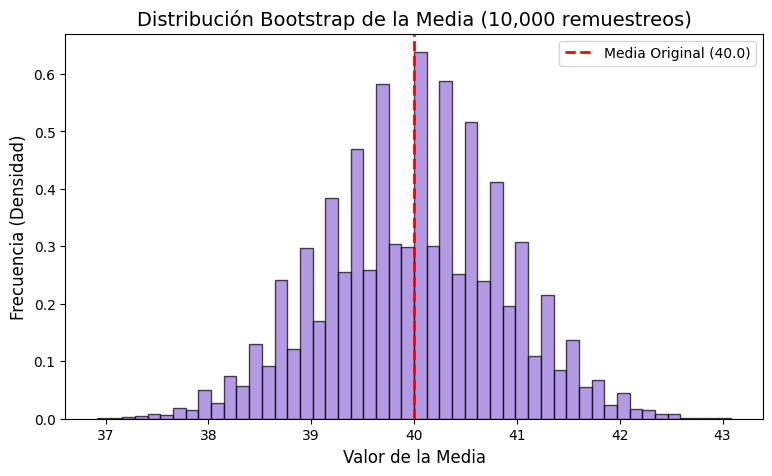

In [34]:
print(f"Datos originales: {datos}")
print(f"Tamaño de muestra (n): {n}")
print(f"Media original: {media_original:.2f}\n")

print("--- RESULTADOS JACKKNIFE ---")
print(f"Error Estándar estimado: {error_estandar_jk:.4f}")

print("\n--- RESULTADOS BOOTSTRAP ---")
print(f"Error Estándar estimado: {error_estandar_boot:.4f}")

plt.figure(figsize=(9, 5))
plt.hist(lista_medias_boot, bins=50, color='mediumpurple', edgecolor='black', alpha=0.7, density=True)
plt.axvline(media_original, color='red', linestyle='dashed', linewidth=2, label=f'Media Original ({media_original})')
plt.title('Distribución Bootstrap de la Media (10,000 remuestreos)', fontsize=14)
plt.xlabel('Valor de la Media', fontsize=12)
plt.ylabel('Frecuencia (Densidad)', fontsize=12)
plt.legend()
plt.show()